# Synthetic vp/vs DLI — vs as Two Unknown Subintervals

This notebook extends `synthetic_vp_vs_dli.ipynb` by making the `vs` model space itself reflect a known zero region. Instead of representing `vs` on the whole interval and then forcing the truth to vanish there, we declare a middle band $[0.4, 0.6]$ where `vs` is known to be zero and parameterize only the two unknown pieces.

The `vs` space is therefore the direct sum

$$
\mathcal{M}_{vs} = \mathcal{M}_{vs,\mathrm{left}} \oplus \mathcal{M}_{vs,\mathrm{right}},
$$

where the two subspaces live on $[0, 0.4]$ and $[0.6, 1]$. The full model space is

$$
\mathcal{M} = \mathcal{M}_{vp} \oplus \mathcal{M}_{vs}.
$$

This is a cleaner inverse formulation than the previous notebook because the zero band is removed from the unknowns rather than merely hidden in the true model.

The admissible property set is

$$
\mathcal{U} = \mathcal{T}\left(\mathcal{B} \cap G^{-1}(\tilde{d} - \mathcal{V})\right),
$$

where both $\mathcal{B}$ (model prior) and $\mathcal{V}$ (data-confidence set) are norm balls represented by `BallSupportFunction`.


In [8]:
from intervalinf import (
    IntervalDomain,
    Lebesgue,
    Function,
    KnownRegion,
    PartitionedLebesgueSpace,
)
from intervalinf import IntegrationConfig, ParallelConfig, LebesgueIntegrationConfig
from intervalinf.providers import NormalModesProvider, BumpFunctionProvider, NullFunctionProvider
from intervalinf.operators import SOLAOperator

from pygeoinf import EuclideanSpace, RowLinearOperator, HilbertSpaceDirectSum
from pygeoinf.convex_analysis import BallSupportFunction
from pygeoinf.backus_gilbert import DualMasterCostFunction
from pygeoinf.convex_optimisation import (
    ProximalBundleMethod,
    solve_support_values,
    best_available_qp_solver,
)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

figures_folder = 'synthetic_vp_vs_zero_region_dli_figures'
os.makedirs(figures_folder, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


## Numerical Configuration

The `vp` block is a standard basis-free `Lebesgue` space on $[0,1]$. The `vs` block is built as a partitioned space with a known zero band on $[0.4, 0.6]$, so only the left and right subintervals are part of the inverse problem.

In [ ]:
Lebesgue_integration_cfg = LebesgueIntegrationConfig(
    inner_product=IntegrationConfig(method='trapz', n_points=512),
    dual=IntegrationConfig(method='trapz', n_points=512),
    general=IntegrationConfig(method='trapz', n_points=512),
)

sola_integration_cfg = IntegrationConfig(method='trapz', n_points=768)
parallel_cfg = ParallelConfig(enabled=True, n_jobs=12)
function_domain = IntervalDomain(0.0, 1.0)
VS_ZERO_A = 0.4
VS_ZERO_B = 0.6
vs_zero_domain = function_domain.restriction_to_subinterval(VS_ZERO_A, VS_ZERO_B)
N = 10
N_d = 100
N_p = 2

M_vp = Lebesgue(
    0, function_domain, basis=None,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)
M_vs_full = Lebesgue(
    0, function_domain, basis=None,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)
vs_zero_region = KnownRegion.zero(
    vs_zero_domain,
    dim=0,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)
vs_partition = PartitionedLebesgueSpace(
    function_domain,
    [vs_zero_region],
    dims=[0, 0],
    basis=None,
    integration_config=Lebesgue_integration_cfg,
    parallel_config=parallel_cfg,
)
M_vs = vs_partition.model_space
M_vs_left = vs_partition.get_unknown_space(0)
M_vs_right = vs_partition.get_unknown_space(1)
M_model = HilbertSpaceDirectSum([M_vp, M_vs])
D = EuclideanSpace(N_d)
P = EuclideanSpace(N_p)

x = function_domain.uniform_mesh(1000)

print(f'Domain            : [{function_domain.a}, {function_domain.b}]')
print(f'Known vs zero band: [{VS_ZERO_A}, {VS_ZERO_B}]')
print(f'vs unknown pieces : {[(d.a, d.b) for d in vs_partition.unknown_intervals]}')
print(f'Data dim          : {N_d}')
print(f'Property dim      : {N_p}')
print(f'SOLA n_points     : {sola_integration_cfg.n_points}')

Domain            : [0.0, 1.0]
Known vs zero band: [0.4, 0.6]
vs unknown pieces : [(0.0, 0.4), (0.6, 1.0)]
Data dim          : 100
Property dim      : 2
SOLA n_points     : 768


## Synthetic Forward and Property Operators

The `vp` forward block is a standard `SOLAOperator` on the full interval. The `vs` forward block is built with `SOLAOperator.for_direct_sum`, which takes kernels defined on the full interval and restricts them onto the two unknown `vs` subspaces. The property operator still targets two bump-function averages on the `vp` block, while the partitioned `vs` block contributes zero.

In [10]:
vp_modes = NormalModesProvider(
    M_vp,
    n_modes_range=(2, 8),
    coeff_range=(-4.0, 4.0),
    gaussian_width_percent_range=(5, 18),
    freq_range=(0.2, 8.0),
    random_state=7,
)
vs_modes = NormalModesProvider(
    M_vs_full,
    n_modes_range=(3, 9),
    coeff_range=(-3.0, 3.0),
    gaussian_width_percent_range=(6, 20),
    freq_range=(0.3, 10.0),
    random_state=17,
)

G_vp = SOLAOperator(
    M_vp, D, vp_modes,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
G_vs = SOLAOperator.for_direct_sum(
    M_vs,
    D,
    vs_modes,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
G = RowLinearOperator([G_vp, G_vs])

width = 0.18
centers = np.linspace(
    function_domain.a + width / 2,
    function_domain.b - width / 2,
    N_p,
)
target_provider_vp = BumpFunctionProvider(M_vp, centers=centers, default_width=width)
target_provider_vs = NullFunctionProvider(M_vs_full)

T_vp = SOLAOperator(
    M_vp, P, target_provider_vp,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
T_vs = SOLAOperator.for_direct_sum(
    M_vs,
    P,
    target_provider_vs,
    cache_kernels=True,
    integration_config=sola_integration_cfg,
)
T = RowLinearOperator([T_vp, T_vs])

print('Block operators created successfully')
print(f'vs unknown intervals: {[(d.a, d.b) for d in vs_partition.unknown_intervals]}')
print(f'Property centres    : {np.round(centers, 3)}')

Block operators created successfully
vs unknown intervals: [(0.0, 0.4), (0.6, 1.0)]
Property centres    : [0.09 0.91]


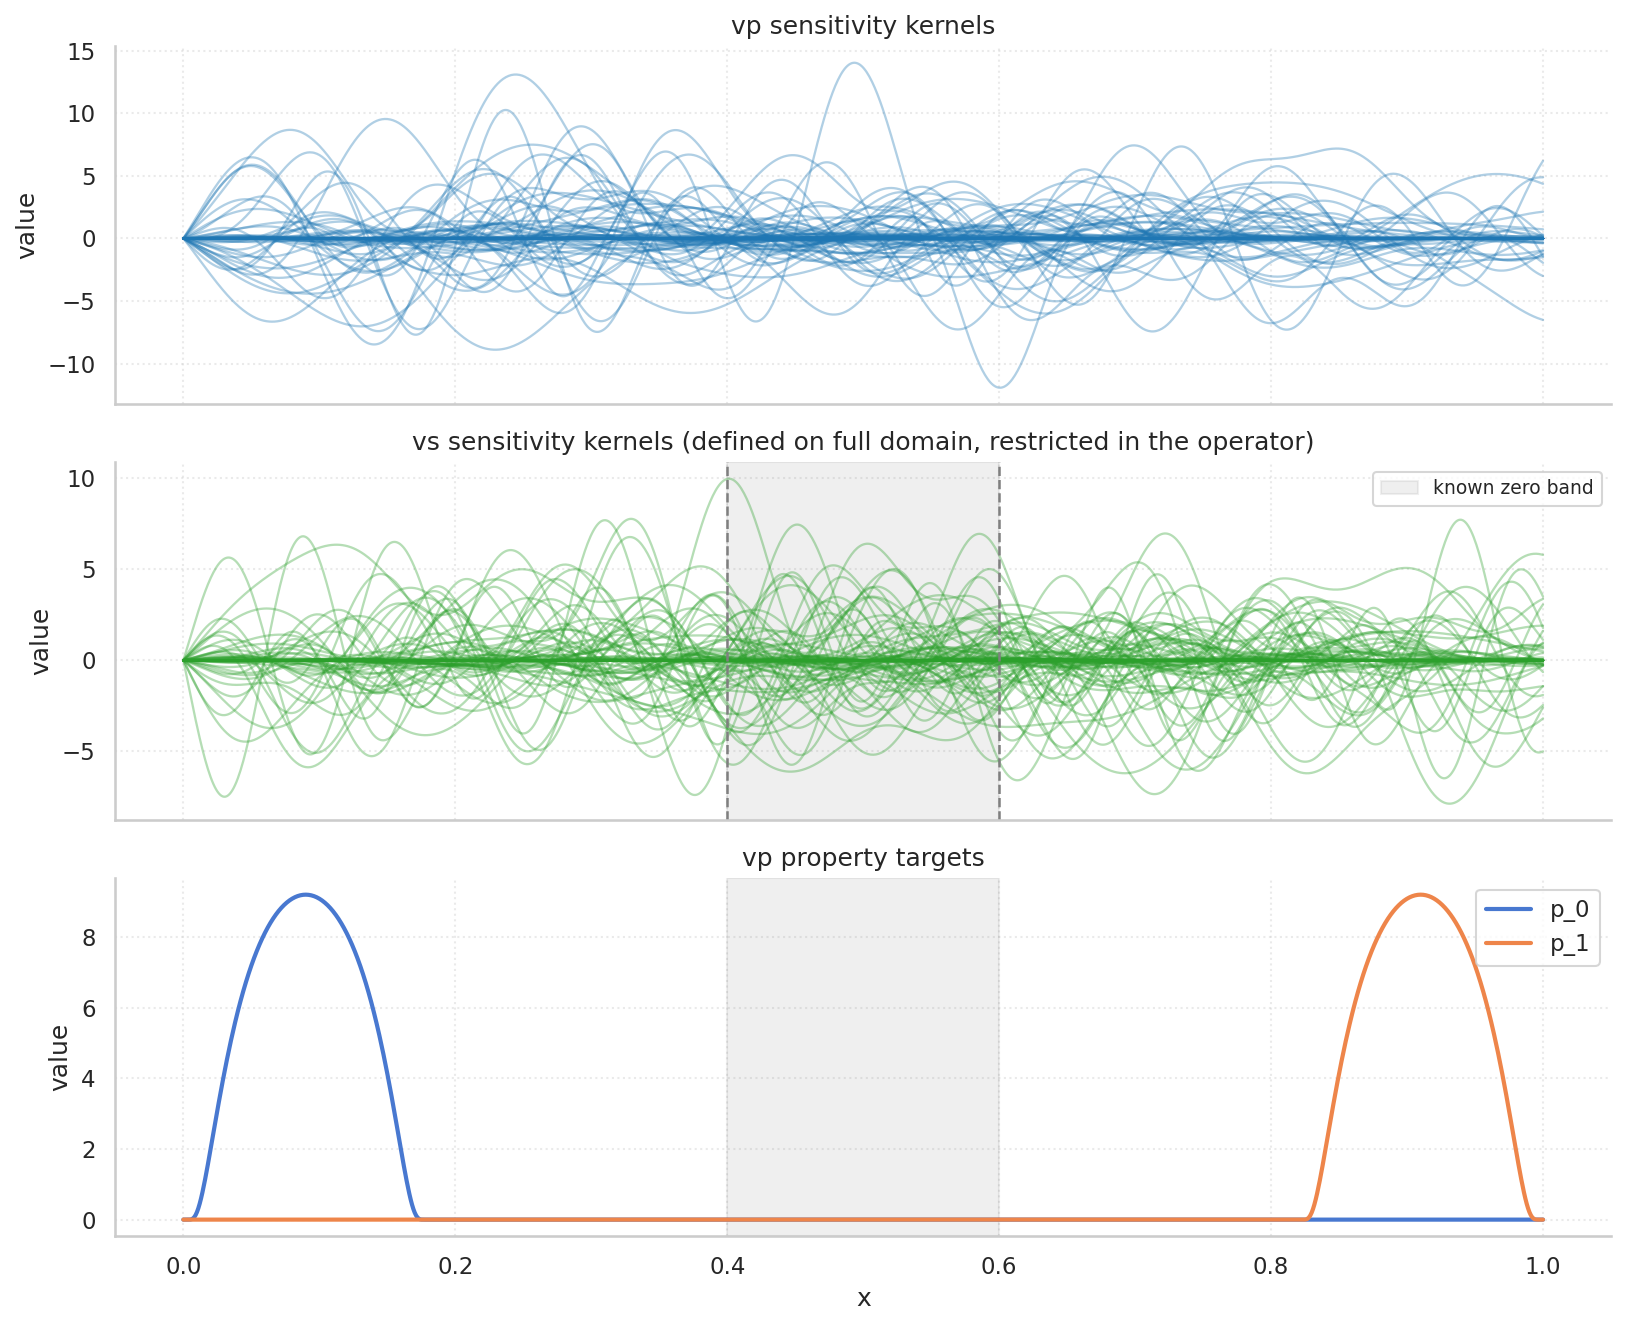

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(11, 9), dpi=150, sharex=True)

for i in range(N_d):
    axs[0].plot(x, G_vp.get_kernel(i).evaluate(x), color='tab:blue', alpha=0.35, linewidth=1.1)
axs[0].set_title(r'vp sensitivity kernels')
axs[0].set_ylabel('value')
axs[0].grid(True, linestyle=':', alpha=0.4)

for i in range(N_d):
    axs[1].plot(x, vs_modes.get_function_by_index(i).evaluate(x), color='tab:green', alpha=0.35, linewidth=1.1)
axs[1].axvspan(VS_ZERO_A, VS_ZERO_B, alpha=0.12, color='tab:gray', label='known zero band')
axs[1].axvline(VS_ZERO_A, color='tab:gray', linestyle='--', linewidth=1.2)
axs[1].axvline(VS_ZERO_B, color='tab:gray', linestyle='--', linewidth=1.2)
axs[1].set_title(r'vs sensitivity kernels (defined on full domain, restricted in the operator)')
axs[1].set_ylabel('value')
axs[1].legend(fontsize=9)
axs[1].grid(True, linestyle=':', alpha=0.4)

for i in range(N_p):
    axs[2].plot(x, T_vp.get_kernel(i).evaluate(x), linewidth=2.0, label=f'p_{i}')
axs[2].axvspan(VS_ZERO_A, VS_ZERO_B, alpha=0.12, color='tab:gray')
axs[2].set_title(r'vp property targets')
axs[2].set_xlabel('x')
axs[2].set_ylabel('value')
axs[2].legend()
axs[2].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'kernels.png'), dpi=200, bbox_inches='tight')
plt.show()

## True Model — vs Lives on Two Unknown Pieces

The true `vp` model is a cosine series on the full interval. The true `vs` model is represented directly as a pair of functions on the two unknown subintervals, and then extended to the full domain by filling the middle band $[0.4, 0.6]$ with the known value zero.

This means the zero band is now part of the model parameterization itself rather than an after-the-fact masking of a full-domain `vs` function.

True properties   : [ 0.60633 -0.76471]
Noise level       : 0.33848
||d_bar||         : 11.27367
||noise||         : 3.07872
vs unknown pieces : [(0.0, 0.4), (0.6, 1.0)]
max |vs| in zero band [0.4, 0.6] : 0.00e+00


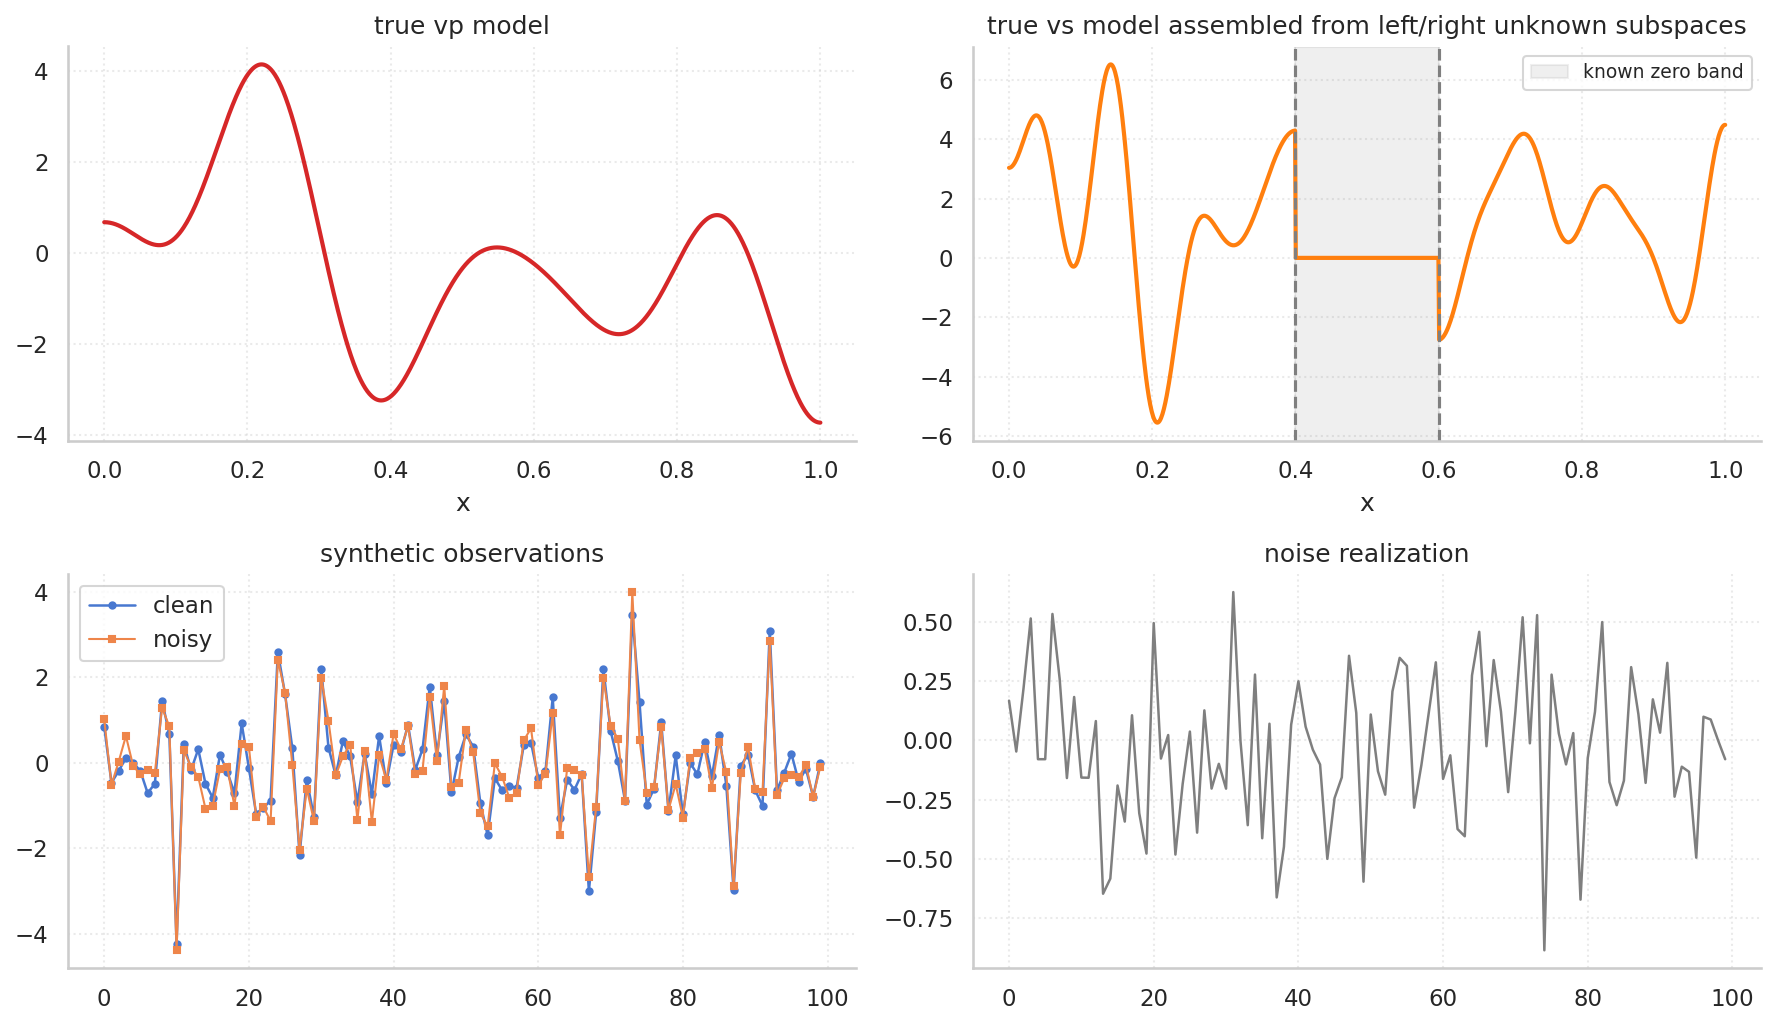

In [12]:
def cosine_series_function(space, coeffs):
    coeffs = np.asarray(coeffs, dtype=float)
    a = space.function_domain.a
    b = space.function_domain.b
    length = b - a

    def evaluate(x):
        x = np.asarray(x, dtype=float)
        xi = (x - a) / length
        values = np.zeros_like(xi, dtype=float)
        if coeffs.size > 0:
            values += coeffs[0] / np.sqrt(length)
        for k, ck in enumerate(coeffs[1:], start=1):
            values += ck * np.sqrt(2.0 / length) * np.cos(np.pi * k * xi)
        return values

    return Function(space, evaluate_callable=evaluate)


vp_coeffs = np.random.RandomState(42).uniform(-1.0, 1.0, N)
vs_left_coeffs = np.random.RandomState(24).uniform(-1.0, 1.0, N)
vs_right_coeffs = np.random.RandomState(25).uniform(-1.0, 1.0, N)

m_bar_vp = cosine_series_function(M_vp, vp_coeffs)
m_bar_vs_left = cosine_series_function(M_vs_left, vs_left_coeffs)
m_bar_vs_right = cosine_series_function(M_vs_right, vs_right_coeffs)
m_bar_vs = [m_bar_vs_left, m_bar_vs_right]
m_bar_vs_full = vs_partition.extend_to_full_domain(m_bar_vs, name='true_vs')
m_bar = [m_bar_vp, m_bar_vs]

true_props = T(m_bar)
d_bar = G(m_bar)
noise_level = 0.08 * max(np.max(np.abs(d_bar)), 1e-8)
np.random.seed(42)
noise_vector = np.random.normal(0.0, noise_level, size=N_d)
d_tilde = d_bar + noise_vector

band_mesh = np.linspace(VS_ZERO_A, VS_ZERO_B, 100)
max_zero_band_value = np.max(np.abs(m_bar_vs_full.evaluate(band_mesh)))

print(f'True properties   : {np.round(true_props, 5)}')
print(f'Noise level       : {noise_level:.5f}')
print(f'||d_bar||         : {D.norm(d_bar):.5f}')
print(f'||noise||         : {D.norm(noise_vector):.5f}')
print(f'vs unknown pieces : {[(d.a, d.b) for d in vs_partition.unknown_intervals]}')
print(f'max |vs| in zero band [{VS_ZERO_A}, {VS_ZERO_B}] : {max_zero_band_value:.2e}')

fig, axs = plt.subplots(2, 2, figsize=(12, 7), dpi=150)

axs[0, 0].plot(x, m_bar_vp.evaluate(x), color='tab:red', linewidth=2.0)
axs[0, 0].set_title('true vp model')
axs[0, 0].set_xlabel('x')
axs[0, 0].grid(True, linestyle=':', alpha=0.4)

axs[0, 1].plot(x, m_bar_vs_full.evaluate(x), color='tab:orange', linewidth=2.0)
axs[0, 1].axvspan(VS_ZERO_A, VS_ZERO_B, alpha=0.12, color='tab:gray', label='known zero band')
axs[0, 1].axvline(VS_ZERO_A, color='tab:gray', linestyle='--', linewidth=1.5)
axs[0, 1].axvline(VS_ZERO_B, color='tab:gray', linestyle='--', linewidth=1.5)
axs[0, 1].set_title('true vs model assembled from left/right unknown subspaces')
axs[0, 1].set_xlabel('x')
axs[0, 1].legend(fontsize=9)
axs[0, 1].grid(True, linestyle=':', alpha=0.4)

axs[1, 0].plot(np.arange(N_d), d_bar, marker='o', markersize=3, linewidth=1.2, label='clean')
axs[1, 0].plot(np.arange(N_d), d_tilde, marker='s', markersize=3, linewidth=1.0, label='noisy')
axs[1, 0].set_title('synthetic observations')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle=':', alpha=0.4)

axs[1, 1].plot(np.arange(N_d), noise_vector, color='tab:gray', linewidth=1.2)
axs[1, 1].set_title('noise realization')
axs[1, 1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'data.png'), dpi=200, bbox_inches='tight')
plt.show()

## Prior Set, Data-Confidence Set, and DLI Solve

Both convex sets are norm balls. The model-prior ball now lives on
$\mathcal{M}_{vp} \oplus (\mathcal{M}_{vs,\mathrm{left}} \oplus \mathcal{M}_{vs,\mathrm{right}})$,
so the known zero band is excluded from the unknown parameterization altogether. This is the key difference from the previous notebook version: the structural zero information is encoded in the model space itself, not only in the chosen truth.

In [13]:
m_0 = M_model.zero
model_radius = 1.35 * M_model.norm(m_bar)
data_radius = 1.25 * D.norm(noise_vector)

model_prior_support = BallSupportFunction(M_model, m_0, model_radius)
data_error_support = BallSupportFunction(D, D.zero, data_radius)

prior_qs = [P.basis_vector(i) for i in range(P.dim)]
prior_upper = np.array([model_prior_support(T.adjoint(q)) for q in prior_qs])
prior_lower = np.array([
    -model_prior_support(M_model.multiply(-1.0, T.adjoint(q)))
    for q in prior_qs
])
prior_mid = 0.5 * (prior_lower + prior_upper)
prior_half = 0.5 * (prior_upper - prior_lower)

cost = DualMasterCostFunction(
    D, P, M_model,
    G, T,
    model_prior_support,
    data_error_support,
    d_tilde,
    P.basis_vector(0),
)

bundle_solver = ProximalBundleMethod(
    cost,
    rho0=1.0,
    rho_factor=2.0,
    tolerance=1e-4,
    max_iterations=300,
    bundle_size=30,
    qp_solver=best_available_qp_solver(),
)

basis_dirs = [P.basis_vector(i) for i in range(P.dim)]
neg_basis_dirs = [P.multiply(-1.0, P.basis_vector(i)) for i in range(P.dim)]
lambda0 = D.zero

solve_t0 = time.perf_counter()
upper_bounds, _, upper_diagnostics = solve_support_values(
    cost, basis_dirs, bundle_solver, lambda0, n_jobs=2
)
lower_neg_values, _, lower_diagnostics = solve_support_values(
    cost, neg_basis_dirs, bundle_solver, lambda0, n_jobs=2
)
solve_elapsed = time.perf_counter() - solve_t0

lower_bounds = -lower_neg_values
mean_values = 0.5 * (lower_bounds + upper_bounds)
property_errors = 0.5 * (upper_bounds - lower_bounds)
reduction = prior_half / np.maximum(property_errors, 1e-12)
within_bounds = int(np.sum((true_props >= lower_bounds) & (true_props <= upper_bounds)))
total_bundle_iterations = sum(d.num_iterations for d in upper_diagnostics + lower_diagnostics)

print(f'Model radius             : {model_radius:.5f}')
print(f'Data radius              : {data_radius:.5f}')
print(f'Solve time               : {solve_elapsed:.2f} s')
print(f'Total bundle iterations  : {total_bundle_iterations}')
print(f'True properties captured : {within_bounds}/{N_p}')

for i in range(N_p):
    inside = lower_bounds[i] <= true_props[i] <= upper_bounds[i]
    print(
        f'p_{i}: prior=[{prior_lower[i]:.4f}, {prior_upper[i]:.4f}]  ' +
        f'post=[{lower_bounds[i]:.4f}, {upper_bounds[i]:.4f}]  ' +
        f'true={true_props[i]:.4f}  inside={inside}'
    )

Model radius             : 4.25950
Data radius              : 3.84840
Solve time               : 27.00 s
Total bundle iterations  : 282
True properties captured : 2/2
p_0: prior=[-11.6661, 11.6661]  post=[-2.3821, 2.9618]  true=0.6063  inside=True
p_1: prior=[-11.6661, 11.6661]  post=[-5.7198, 3.9080]  true=-0.7647  inside=True


## Results

The first panel compares prior and posterior intervals for the two target properties.
The second panel shows the half-width reduction achieved by the data.

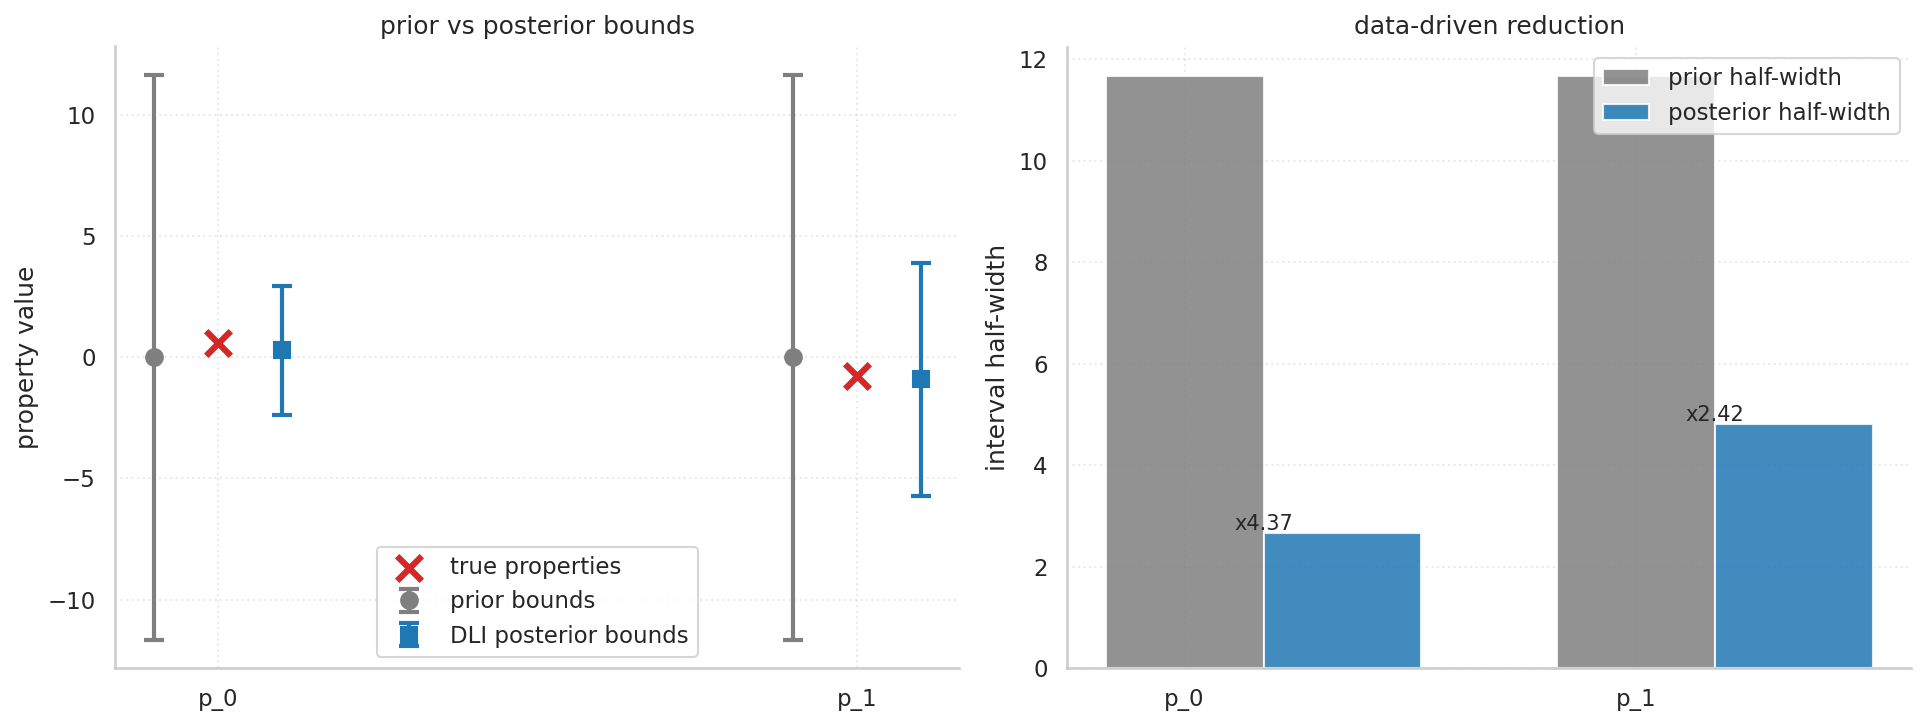

SYNTHETIC VP/VS (PARTITIONED VS) DLI SUMMARY
Model blocks             : vp + (vs_left ⊕ vs_right)
Known zero band          : [0.4, 0.6]
vs unknown intervals     : [(0.0, 0.4), (0.6, 1.0)]
Data dimension           : 100
Property dimension       : 2
Mean prior half-width    : 11.66613
Mean posterior half-width: 3.74291
Mean reduction factor    : 3.39x
Solve time               : 27.00 s


In [14]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

offsets = np.array([-0.1, 0.1])
axs[0].errorbar(
    np.arange(N_p) + offsets[0], prior_mid, yerr=prior_half, fmt='o',
    color='tab:gray', capsize=5, capthick=2, markersize=8, linewidth=2,
    label='prior bounds'
)
axs[0].errorbar(
    np.arange(N_p) + offsets[1], mean_values, yerr=property_errors, fmt='s',
    color='tab:blue', capsize=5, capthick=2, markersize=8, linewidth=2,
    label='DLI posterior bounds'
)
axs[0].scatter(
    np.arange(N_p), true_props, color='tab:red', marker='x',
    s=140, linewidths=3, zorder=10, label='true properties'
)
axs[0].set_xticks(np.arange(N_p))
axs[0].set_xticklabels([f'p_{i}' for i in range(N_p)])
axs[0].set_ylabel('property value')
axs[0].set_title('prior vs posterior bounds')
axs[0].legend()
axs[0].grid(True, linestyle=':', alpha=0.4)

axs[1].bar(np.arange(N_p), prior_half, width=0.35, align='edge', color='tab:gray', alpha=0.85, label='prior half-width')
axs[1].bar(np.arange(N_p) + 0.35, property_errors, width=0.35, align='edge', color='tab:blue', alpha=0.85, label='posterior half-width')
for i in range(N_p):
    axs[1].text(i + 0.35, property_errors[i] + 0.01 * np.max(property_errors), f'x{reduction[i]:.2f}', ha='center', fontsize=10)
axs[1].set_xticks([i + 0.175 for i in range(N_p)])
axs[1].set_xticklabels([f'p_{i}' for i in range(N_p)])
axs[1].set_ylabel('interval half-width')
axs[1].set_title('data-driven reduction')
axs[1].legend()
axs[1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figures_folder, 'results.png'), dpi=200, bbox_inches='tight')
plt.show()

print('=' * 60)
print('SYNTHETIC VP/VS (PARTITIONED VS) DLI SUMMARY')
print('=' * 60)
print('Model blocks             : vp + (vs_left ⊕ vs_right)')
print(f'Known zero band          : [{VS_ZERO_A}, {VS_ZERO_B}]')
print(f'vs unknown intervals     : {[(d.a, d.b) for d in vs_partition.unknown_intervals]}')
print(f'Data dimension           : {N_d}')
print(f'Property dimension       : {N_p}')
print(f'Mean prior half-width    : {np.mean(prior_half):.5f}')
print(f'Mean posterior half-width: {np.mean(property_errors):.5f}')
print(f'Mean reduction factor    : {np.mean(reduction):.2f}x')
print(f'Solve time               : {solve_elapsed:.2f} s')
print('=' * 60)